In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
print("House Price Prediction Project")


House Price Prediction Project


In [ ]:
df_from_excel= pd.read_csv('/content/house_price_dataset.csv')
df_from_excel


,Bedrooms,Bathrooms,SquareFeet,LotSize,Garage,YearBuilt,Location,PropertyType,Condition,HeatingType,Balcony,Pool,Fireplace,AirConditioning,NeighborhoodScore,SchoolRating,CrimeRate,WalkScore,Price
0,4,1,2094,13964,0,2008,Industrial Area,Townhouse,Fair,Heat Pump,No,Yes,No,Yes,6.61,10,2.70,64,563819
1,1,4,821,8396,3,1994,Park Adjacent,Townhouse,Fair,Electric,No,Yes,Yes,Yes,6.93,7,4.06,64,500904
2,5,3,1446,16502,1,1973,Urban Core,Condo,Good,Gas,No,Yes,No,Yes,3.61,9,7.67,35,553154
3,4,2,3873,3021,1,2023,Historic District,Duplex,Good,Heat Pump,Yes,No,No,Yes,7.63,10,2.57,62,898437
4,5,2,1678,11268,3,1995,Beachfront,Single Family,Excellent,Heat Pump,Yes,Yes,No,Yes,4.47,7,2.59,8,1537910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4,1,825,16928,1,2003,School District,Townhouse,Fair,Electric,No,Yes,No,Yes,7.76,10,4.67,55,522820
4996,1,1,3166,19228,3,1986,Lakeside,Townhouse,Good,Solar,Yes,No,Yes,Yes,5.49,8,2.35,70,770256
4997,2,1,3889,12208,1,1983,Residential Area,Condo,Fair,Electric,No,No,No,Yes,7.52,5,7.59,14,597693
4998,2,1,1821,3756,0,1996,Beachfront,Single Family,Poor,Solar,Yes,No,No,Yes,6.28,7,8.04,38,733612


In [ ]:
print('SHAPE')
df_from_excel.shape

SHAPE


(5000, 19)

In [ ]:
print('COLUMNS')
df_from_excel.columns

COLUMNS


Index(['Bedrooms', 'Bathrooms', 'SquareFeet', 'LotSize', 'Garage', 'YearBuilt',
       'Location', 'PropertyType', 'Condition', 'HeatingType', 'Balcony',
       'Pool', 'Fireplace', 'AirConditioning', 'NeighborhoodScore',
       'SchoolRating', 'CrimeRate', 'WalkScore', 'Price'],
      dtype='object')

In [ ]:
print('ALL INFO')
df_from_excel.describe()

ALL INFO


,Bedrooms,Bathrooms,SquareFeet,LotSize,Garage,YearBuilt,NeighborhoodScore,SchoolRating,CrimeRate,WalkScore,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,3.483200,2.500000,2403.095600,11078.769400,1.489600,1996.57040,5.485502,7.489200,5.017330,49.292000,8.328586e+05
std,1.700558,1.119397,927.741683,5215.397434,1.128072,15.70661,1.438688,1.729764,2.305437,28.849624,3.562616e+05
min,1.000000,1.000000,800.000000,2001.000000,0.000000,1970.00000,3.000000,5.000000,1.000000,1.000000,2.385530e+05
25%,2.000000,1.000000,1593.750000,6577.500000,0.000000,1983.00000,4.250000,6.000000,3.000000,24.000000,5.782450e+05
50%,3.000000,3.000000,2411.000000,11143.000000,1.000000,1997.00000,5.490000,7.000000,5.050000,48.500000,7.549830e+05
75%,5.000000,3.000000,3206.000000,15547.250000,3.000000,2010.00000,6.700000,9.000000,7.000000,74.000000,1.000788e+06
max,6.000000,4.000000,3999.000000,19982.000000,3.000000,2023.00000,8.000000,10.000000,9.000000,100.000000,2.916490e+06


In [ ]:
print('DATA TYPES')
df_from_excel.dtypes

DATA TYPES


,0
Bedrooms,int64
Bathrooms,int64
SquareFeet,int64
LotSize,int64
Garage,int64
YearBuilt,int64
Location,object
PropertyType,object
Condition,object
HeatingType,object


In [ ]:
print(f"\n💰 Price Analysis:")
print(f"Mean price: ${df_from_excel['Price'].mean():,.2f}")
print(f"Median price: ${df_from_excel['Price'].median():,.2f}")
print(f"Min price: ${df_from_excel['Price'].min():,.2f}")
print(f"Max price: ${df_from_excel['Price'].max():,.2f}")
print(f"Standard deviation: ${df_from_excel['Price'].std():,.2f}")


💰 Price Analysis:
Mean price: $832,858.56
Median price: $754,983.00
Min price: $238,553.00
Max price: $2,916,490.00
Standard deviation: $356,261.62


In [ ]:
X = df_from_excel.drop('Price', axis=1)
y = df_from_excel['Price']


In [ ]:
#handle categorial variables
categorical_columns = ['Location', 'PropertyType', 'Condition', 'HeatingType', 'Balcony', 'Pool', 'Fireplace', 'AirConditioning']


In [ ]:
label_encoders = {}
X_encoded = X.copy()


In [ ]:
for col in categorical_columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

Encoded Location: 20 unique values
Encoded PropertyType: 5 unique values
Encoded Condition: 4 unique values
Encoded HeatingType: 5 unique values
Encoded Balcony: 2 unique values
Encoded Pool: 2 unique values
Encoded Fireplace: 2 unique values
Encoded AirConditioning: 2 unique values


In [ ]:
numerical_columns = ['Bedrooms', 'Bathrooms', 'SquareFeet', 'LotSize', 'Garage', 'YearBuilt',
                    'NeighborhoodScore', 'SchoolRating', 'CrimeRate', 'WalkScore']

In [ ]:
scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[numerical_columns] = scaler.fit_transform(X_encoded[numerical_columns])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [ ]:
print("Training set:")
X_train.shape


Training set:


(4000, 18)

In [ ]:
print("Testing set: ")
X_test.shape

Testing set: 


(1000, 18)

In [ ]:
print("Training Linear Regression")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)


Training Linear Regression


In [ ]:
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

In [ ]:
print("Linear Regression Results:")
print(f"  RMSE: ${lr_rmse:,.2f}")
print(f"  MAE: ${lr_mae:,.2f}")
print(f"  R²: {lr_r2:.4f}")

Linear Regression Results:
  RMSE: $254,353.57
  MAE: $195,223.84
  R²: 0.4397


In [ ]:
print("Training Random Forest")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

Training Random Forest


In [ ]:
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

In [ ]:
print(f"Random Forest Results:")
print(f"  RMSE: ${rf_rmse:,.2f}")
print(f"  MAE: ${rf_mae:,.2f}")
print(f"  R²: {rf_r2:.4f}")

Random Forest Results:
  RMSE: $141,540.41
  MAE: $103,078.85
  R²: 0.8265


In [ ]:
print("Training Decision Tree")
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)


Training Decision Tree


In [ ]:
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

In [ ]:
print(f"Decision Tree Results:")
print(f"  RMSE: ${dt_rmse:,.2f}")
print(f"  MAE: ${dt_mae:,.2f}")
print(f"  R²: {dt_r2:.4f}")


Decision Tree Results:
  RMSE: $211,510.84
  MAE: $140,056.94
  R²: 0.6126


In [ ]:
print("\n📊 Model Comparison:")
print("-" * 70)
print(f"{'Model':<20} {'RMSE':<15} {'MAE':<15} {'R²':<10}")
print("-" * 70)
print(f"{'Linear Regression':<20} ${lr_rmse:<14,.0f} ${lr_mae:<14,.0f} {lr_r2:<9.4f}")
print(f"{'Random Forest':<20} ${rf_rmse:<14,.0f} ${rf_mae:<14,.0f} {rf_r2:<9.4f}")
print(f"{'Decision Tree':<20} ${dt_rmse:<14,.0f} ${dt_mae:<14,.0f} {dt_r2:<9.4f}")


📊 Model Comparison:
----------------------------------------------------------------------
Model                RMSE            MAE             R²        
----------------------------------------------------------------------
Linear Regression    $254,354        $195,224        0.4397   
Random Forest        $141,540        $103,079        0.8265   
Decision Tree        $211,511        $140,057        0.6126   


In [ ]:
 #fro finmding best model
 models_r2 = {
    'Linear Regression': lr_r2,
    'Random Forest': rf_r2,
    'Decision Tree': dt_r2,
}

In [ ]:
best_model_name = max(models_r2.keys(), key=lambda x: models_r2[x])
best_r2 = models_r2[best_model_name]

In [ ]:
print("Best Model:best_model_name}")
print("R² Score: {best_r2:.4f}")

Best Model:best_model_name}
R² Score: {best_r2:.4f}


In [ ]:
print("\n🔮 Sample Predictions (Random Forest):")
print("-" * 50)
sample_indices = np.random.choice(len(X_test), 5, replace=False)
for i, idx in enumerate(sample_indices):
    actual_price = y_test.iloc[idx]
    predicted_price = rf_pred[idx]
    error = abs(actual_price - predicted_price)
    error_pct = (error / actual_price) * 100

    print(f"Sample {i+1}:")
    print(f"  Actual Price: ${actual_price:,.2f}")
    print(f"  Predicted Price: ${predicted_price:,.2f}")
    print(f"  Error: ${error:,.2f} ({error_pct:.1f}%)")
    print()


🔮 Sample Predictions (Random Forest):
--------------------------------------------------
Sample 1:
  Actual Price: $1,412,747.00
  Predicted Price: $1,087,361.32
  Error: $325,385.68 (23.0%)

Sample 2:
  Actual Price: $739,949.00
  Predicted Price: $692,990.68
  Error: $46,958.32 (6.3%)

Sample 3:
  Actual Price: $647,207.00
  Predicted Price: $656,263.29
  Error: $9,056.29 (1.4%)

Sample 4:
  Actual Price: $556,721.00
  Predicted Price: $593,133.36
  Error: $36,412.36 (6.5%)

Sample 5:
  Actual Price: $386,301.00
  Predicted Price: $436,461.49
  Error: $50,160.49 (13.0%)



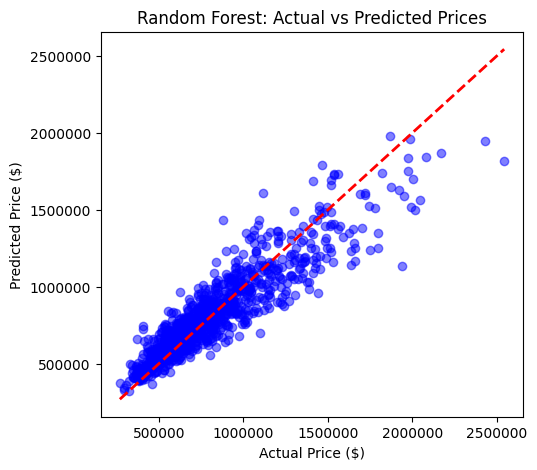

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, rf_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Random Forest: Actual vs Predicted Prices')
plt.ticklabel_format(style='plain', axis='both')

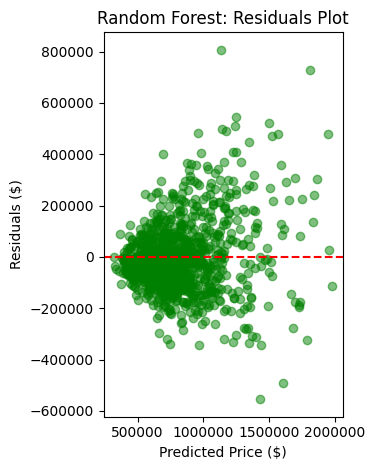

In [ ]:
plt.subplot(1, 2, 2)
residuals = y_test - rf_pred
plt.scatter(rf_pred, residuals, alpha=0.5, color='green')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residuals ($)')
plt.title('Random Forest: Residuals Plot')
plt.ticklabel_format(style='plain', axis='both')
plt.tight_layout()
plt.show()


(0.0, 1.0)

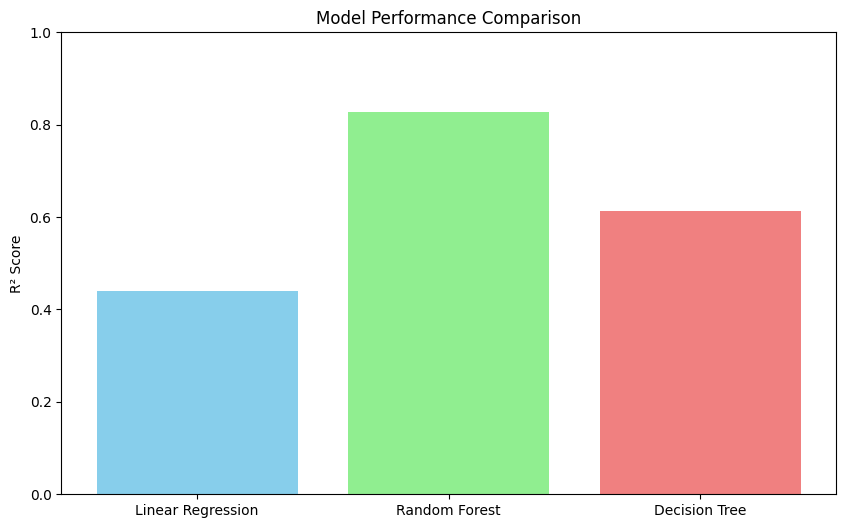

In [ ]:
plt.figure(figsize=(10, 6))
model_names = list(models_r2.keys())
r2_scores = list(models_r2.values())

bars = plt.bar(model_names, r2_scores, color=['skyblue', 'lightgreen', 'lightcoral', 'gold', 'lightpink'])
plt.ylabel('R² Score')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)

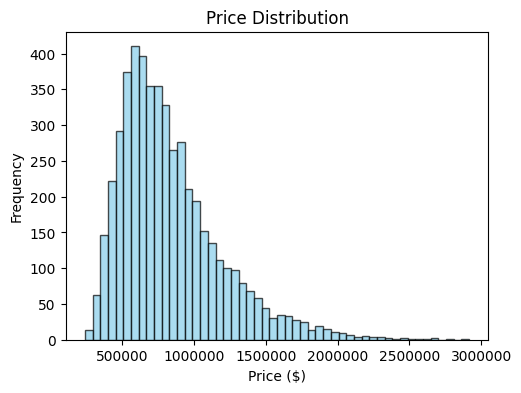

In [ ]:
 #Price distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df_from_excel['Price'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.title('Price Distribution')
plt.ticklabel_format(style='plain', axis='x')

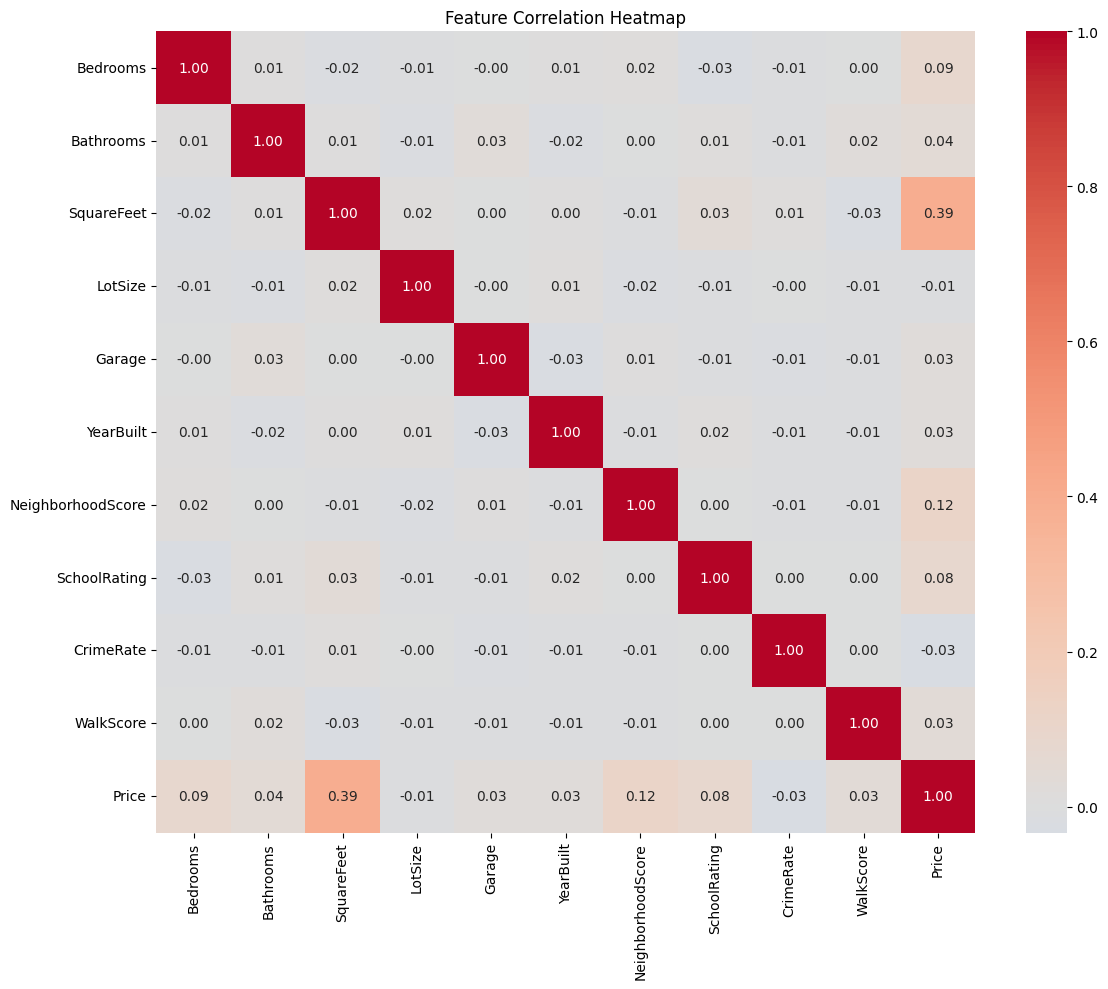

In [ ]:
plt.figure(figsize=(12, 10))
correlation_matrix = df_from_excel.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
print("\t\t\tFINAL SUMMARY\n")
print("\tModels trained thorugh 3 different algorithms")
print("\tBest model: {best_model_name} (R² = {best_r2:.4f})")
print("\n\tSimple House Price Prediction Project Complete!")

			FINAL SUMMARY

	Models trained thorugh 3 different algorithms
	Best model: {best_model_name} (R² = {best_r2:.4f})

	Simple House Price Prediction Project Complete!
